# 금융 법령정보 텍스트 데이터 EDA
`ovdiv_data.json`의 `sections` 내 텍스트(heading/text/note) 데이터만 추출하여 분석합니다.
표(table) 데이터는 제외하고 검색 시스템에 사용할 텍스트 콘텐츠만 다룹니다.

## 1. 데이터 로드

In [1]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

with open("../data/law_data.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"총 문서(조합) 수: {len(data)}")

총 문서(조합) 수: 18


## 2. sections에서 텍스트 데이터만 추출
각 섹션의 `body`에서 `type`이 `heading`, `text`, `note`인 항목만 모아 하나의 본문(content)으로 합칩니다. `table`은 제외합니다.

In [2]:
TEXT_TYPES = ("heading", "text", "note")

rows = []
for doc in data:
    for section in doc["sections"]:
        texts = [b["text"] for b in section["body"] if b["type"] in TEXT_TYPES]
        content = "\n".join(texts)

        tables = [b["rows"] for b in section["body"] if b["type"] == "table"]

        rows.append({
            "csmSeq": doc["csmSeq"],
            "ccfNo": doc["ccfNo"],
            "cciNo": doc["cciNo"],
            "cnpClsNo": doc["cnpClsNo"],
            "section_title": section["title"],
            "content": content,
            "text_length": len(content),
            "n_lines": len(texts),
            "tables": tables,
            "n_tables": len(tables),
        })

df = pd.DataFrame(rows)
df.head()

,csmSeq,ccfNo,cciNo,cnpClsNo,section_title,content,text_length,n_lines,tables,n_tables
0,1771,1,1,1,금융상품,"“금융상품”이란?\n“금융상품”이란 예금 및 대출, 금융투자상품, 보험상품, 신용카...",635,8,"[[[구분, 금융상품 ( 예시 )], [예금성 상품, ▪ 예금 ▪ 예탁금 ▪ 금융기...",2
1,1771,1,1,1,금융소비자의 의미,“금융소비자”란?\n“금융소비자”란 금융상품에 관한 계약의 체결 또는 계약 체결의 ...,447,5,[],0
2,1771,1,1,2,금융상품6대 판매원칙 준수 의무,「금융소비자 보호에 관한 법률」에 따른 금융상품 6대 판매 원칙\n금융상품 판매업자...,94,2,"[[[6 대 판매 원칙, 내용, 위반 시 제재], [적합성원칙, 일반금융소비자의 연...",1
3,1771,1,2,1,청약의 철회,"“청약철회권”이란?\n""청약철회권""이란 금융상품판매업자 또는 금융상품자문업자(이하 ...",870,11,"[[[구분, 청약철회권 행사 기간, 청약철회 효력 발생 시기], [보장성 상품, 일...",2
4,1771,1,2,2,위법계약의 해지,"“위법계약의 해지권”이란?\n""위법계약의 해지권""이란 금융상품판매업자 또는 금융상품...",760,8,[],0


## 3. 기본 정보

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   csmSeq         38 non-null     int64 
 1   ccfNo          38 non-null     int64 
 2   cciNo          38 non-null     int64 
 3   cnpClsNo       38 non-null     int64 
 4   section_title  38 non-null     object
 5   content        38 non-null     object
 6   text_length    38 non-null     int64 
 7   n_lines        38 non-null     int64 
 8   tables         38 non-null     object
 9   n_tables       38 non-null     int64 
dtypes: int64(7), object(3)
memory usage: 3.1+ KB


In [4]:
df.describe()

,csmSeq,ccfNo,cciNo,cnpClsNo,text_length,n_lines,n_tables
count,38.0,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,1771.0,2.394737,1.552632,1.710526,522.210526,7.026316,0.210526
std,0.0,1.103789,0.554947,0.867051,284.349248,3.969389,0.528020
min,1771.0,1.000000,1.000000,1.000000,40.000000,1.000000,0.000000
25%,1771.0,2.000000,1.000000,1.000000,314.750000,4.000000,0.000000
50%,1771.0,2.000000,2.000000,1.000000,443.500000,6.500000,0.000000
75%,1771.0,3.000000,2.000000,2.000000,662.500000,9.000000,0.000000
max,1771.0,4.000000,3.000000,4.000000,1139.000000,18.000000,2.000000


## 4. 섹션 제목 빈도

In [5]:
df["section_title"].value_counts().head(20)

section_title
분쟁조정 절차                2
금융상품                   1
예금보험금 지급 보류            1
분쟁처리 및 분쟁조정            1
휴면예금등                  1
예금자보호제도                1
보호대상 금융회사              1
예금보험금 및 보험사고           1
예금보험금의 지급 절차           1
개별 법령상 예금자보호 개관        1
금융회사 또는 전자금융업자의 책임     1
금융분쟁의 조정               1
분쟁조정의 효력               1
소비자분쟁의 조정              1
한국거래소 시장감시위원회의 분쟁조정    1
금융투자협회의 분쟁조정제도         1
민사조정을 통해 분쟁을 해결        1
약관의 명시와 변경통지 등         1
반환지원신청                 1
금융소비자의 의미              1
Name: count, dtype: int64

## 5. 텍스트 길이 분포

In [6]:
df["text_length"].describe()

count      38.000000
mean      522.210526
std       284.349248
min        40.000000
25%       314.750000
50%       443.500000
75%       662.500000
max      1139.000000
Name: text_length, dtype: float64

<Axes: xlabel='text_length', ylabel='Count'>

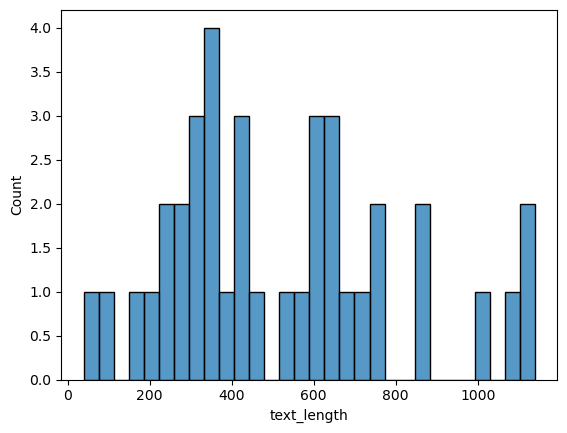

In [7]:
sns.histplot(data=df["text_length"], bins=30)

In [8]:
print("텍스트가 비어있는 섹션 수:", (df["text_length"] == 0).sum())
print("텍스트 길이가 50자 미만인 섹션 수:", (df["text_length"] < 50).sum())
print("텍스트 길이가 1000자 이상인 섹션 수:", (df["text_length"] >= 1000).sum())

텍스트가 비어있는 섹션 수: 0
텍스트 길이가 50자 미만인 섹션 수: 1
텍스트 길이가 1000자 이상인 섹션 수: 4


## 6. 테이블 데이터 점검
표는 chunking 시 의미가 깨지므로, 글자수와 무관하게 하나의 chunk(table chunk)로 유지해야 합니다.
여기서는 표의 크기(행/열)와 텍스트화했을 때의 길이를 점검합니다.

In [9]:
def table_to_text(rows):
    """표(rows: list of list)를 검색/임베딩용 텍스트로 변환"""
    lines = []
    for r in rows:
        lines.append(" | ".join(r))
    return "\n".join(lines)


table_rows = []
for _, row in df.iterrows():
    for t_idx, table in enumerate(row["tables"]):
        table_text = table_to_text(table)
        table_rows.append({
            "csmSeq": row["csmSeq"],
            "ccfNo": row["ccfNo"],
            "cciNo": row["cciNo"],
            "cnpClsNo": row["cnpClsNo"],
            "section_title": row["section_title"],
            "table_index": t_idx,
            "n_rows": len(table),
            "n_cols": len(table[0]) if table else 0,
            "table_text_length": len(table_text),
        })

table_df = pd.DataFrame(table_rows)
print(f"총 표 개수: {len(table_df)}")
table_df.describe()

총 표 개수: 8


,csmSeq,ccfNo,cciNo,cnpClsNo,table_index,n_rows,n_cols,table_text_length
count,8.0,8.00000,8.000000,8.000000,8.00000,8.000000,8.000000,8.000000
mean,1771.0,1.50000,1.500000,1.500000,0.25000,5.500000,2.500000,701.250000
std,0.0,0.92582,0.534522,1.069045,0.46291,3.422614,0.534522,497.670502
min,1771.0,1.00000,1.000000,1.000000,0.00000,2.000000,2.000000,136.000000
25%,1771.0,1.00000,1.000000,1.000000,0.00000,3.750000,2.000000,347.000000
50%,1771.0,1.00000,1.500000,1.000000,0.00000,4.500000,2.500000,691.500000
75%,1771.0,1.50000,2.000000,1.250000,0.25000,6.250000,3.000000,829.000000
max,1771.0,3.00000,2.000000,4.000000,1.00000,13.000000,3.000000,1745.000000


In [10]:
if not table_df.empty:
    print("=== 표 텍스트 길이 분포 ===")
    print(table_df["table_text_length"].describe())
    print("\n=== 표 텍스트 길이가 가장 긴 표 TOP 5 ===")
    print(table_df.sort_values("table_text_length", ascending=False)[
        ["section_title", "n_rows", "n_cols", "table_text_length"]
    ].head(5))

=== 표 텍스트 길이 분포 ===
count       8.000000
mean      701.250000
std       497.670502
min       136.000000
25%       347.000000
50%       691.500000
75%       829.000000
max      1745.000000
Name: table_text_length, dtype: float64

=== 표 텍스트 길이가 가장 긴 표 TOP 5 ===
       section_title  n_rows  n_cols  table_text_length
7    개별 법령상 예금자보호 개관      13       3               1745
6          보호대상 금융회사       6       2                871
2  금융상품6대 판매원칙 준수 의무       7       3                815
3             청약의 철회       4       3                741
0               금융상품       5       2                642


## 7. 결측 / 빈 콘텐츠 점검

In [11]:
df.isnull().sum()

csmSeq           0
ccfNo            0
cciNo            0
cnpClsNo         0
section_title    0
content          0
text_length      0
n_lines          0
tables           0
n_tables         0
dtype: int64

## 8. 중복 콘텐츠 점검

In [12]:
dup_content = df[df.duplicated(subset=["content"], keep=False) & (df["content"].str.strip() != "")]
print(f"중복 content를 가진 섹션 수: {len(dup_content)}")
dup_content[["csmSeq", "ccfNo", "cciNo", "cnpClsNo", "section_title", "text_length"]].head(10)

중복 content를 가진 섹션 수: 0


,csmSeq,ccfNo,cciNo,cnpClsNo,section_title,text_length


## 9. 텍스트 길이 상/하위 샘플 확인

In [13]:
print("=== 가장 긴 텍스트 (상위 1개) ===")
longest = df.sort_values("text_length", ascending=False).iloc[0]
print(f"제목: {longest['section_title']} (length={longest['text_length']})\n")
print(longest["content"][:1000])

=== 가장 긴 텍스트 (상위 1개) ===
제목: 분쟁조정 절차 (length=1139)

조정 신청
조정대상기관, 금융소비자 및 그 밖의 이해관계인은 금융과 관련하여 분쟁이 있을 때에는 금융감독원장에게 분쟁조정을 신청할 수 있습니다(「금융소비자 보호에 관한 법률」 제36조제1항).
다수의 신청인이 공동으로 분쟁조정을 신청하는 경우에는 신청인 중 3명 이내의 대표자를 선정할 수 있습니다(「금융소비자 보호에 관한 법률 시행령」 제33조제1항).
※ 인터넷 신청: <금융감독원 홈페이지(https://www.fss.or.kr/)-민원·신고-민원신청>
※ 방문 또는 우편 신청: 금융감독원 본점(지점)(☎1332)
합의 권고
금융감독원장은 분쟁조정 신청을 받았을 때에는 관계 당사자에게 그 내용을 통지하고 합의를 권고할 수 있습니다(「금융소비자 보호에 관한 법률」 제36조제2항 본문).
금융감독원장은 합의를 권고하기 위해 필요하다고 인정하는 경우에는 당사자(대리인을 포함)에게 의견의 진술 또는 자료의 제출을 요구할 수 있습니다(「금융소비자 보호에 관한 법률 시행령」 제33조제3항).
위원회 회부
금융감독원장은 분쟁조정 신청을 받은 날부터 30일 이내에 합의가 이루어지지 않았을 때에는 지체 없이 조정위원회에 회부해야 합니다(「금융소비자 보호에 관한 법률」 제36조제4항).
다만, 분쟁조정의 신청내용이 다음의 어느 하나에 해당하는 경우에는 조정위원회에 회부하지 않을 수 있습니다(「금융소비자 보호에 관한 법률」 제36조제2항 단서 및「금융소비자 보호에 관한 법률 시행령」 제33조제4항).
조정위원회 심의 및 조정안 작성
조정위원회는 조정을 회부받았을 때에는 이를 심의하여 조정안을 60일 이내에 작성해야 합니다(「금융소비자 보호에 관한 법률」 제36조제5항).
조정안 수락여부
금융감독원장은 조정위원회가 조정안을 작성하였을 때에는 신청인과 관계 당사자에게 제시하고 수락을 권고할 수 있습니다(「금융소비자 보호에 관한 법률」 제36조제6항).
신청인과 관계 당사자가 조정안을 제시받

In [14]:
print("=== 가장 짧은 텍스트 (0 제외, 하위 5개) ===")
shortest = df[df["text_length"] > 0].sort_values("text_length").head(5)
cnt = 1
for _, row in shortest.iterrows():
    print(f"{cnt}. 제목: [{row['section_title']}] (length={row['text_length']}) | 내용: {row['content']}")
    cnt += 1

=== 가장 짧은 텍스트 (0 제외, 하위 5개) ===
1. 제목: [개별 법령상 예금자보호 개관] (length=40) | 내용: 개별 법령에 따른 예금자보호 규정 및 보험금 지급한도는 다음과 같습니다.
2. 제목: [금융상품6대 판매원칙 준수 의무] (length=94) | 내용: 「금융소비자 보호에 관한 법률」에 따른 금융상품 6대 판매 원칙
금융상품 판매업자등이 준수해야 할 금융상품 6대 판매원칙의 주요내용 및 위반 시 제재는 다음과 같습니다.
3. 제목: [예금자보호제도] (length=167) | 내용: “예금자보호제도”란?
“예금자보호제도”는 금융회사가 영업정지나 파산 등으로 예금 등을 지급할 수 없는 경우 예금보험공사가 금융회사를 대신하여 예금 등을 지급하는 제도를 말합니다(「예금자보호법」 제1조및 예금보험공사 홈페이지(https://www.kdic.or.kr)-제도·정책-예금자보호제도 참조).
4. 제목: [금융분쟁의 조정] (length=198) | 내용: 금융분쟁조정위원회의 설치
조정대상기관, 금융소비자 및 그 밖의 이해관계인 사이에 발생하는 금융 관련 분쟁의 조정에 관한 사항을 심의·의결하기 위하여 금융감독원에 금융분쟁조정위원회(이하 “조정위원회”라 함)를 둡니다(「금융소비자 보호에 관한 법률」 제33조).
※ “조정대상기관”이란 다음의 기관을 말합니다(「금융위원회의 설치 등에 관한 법률」 제38조).
5. 제목: [다른 사람의 실명으로 하는 금융거래 금지] (length=236) | 내용: 불법·탈법 목적의 금융거래 금지
누구든지 불법재산의 은닉, 자금세탁행위 또는 공중협박자금조달행위 및 강제집행의 면탈이나 그 밖에 탈법행위를 목적으로 다른 사람의 실명으로 금융거래를 해서는 안 됩니다(「금융실명거래 및 비밀보장에 관한 법률」 제3조제3항).
이를 위반하면 5년 이하의 징역 또는 5천만원 이하의 벌금에 처해지며, 징역형과 벌금형이 병과(倂科)될 수 있습니다(「금융실명거래 및 비밀보장에 관한 법률」 제6조).


## 10. 형태소 기반 분석 (Kiwi)
`kiwipiepy`를 사용해 명사를 추출하고 빈도를 분석합니다.

In [15]:
from kiwipiepy import Kiwi
from collections import Counter

kiwi = Kiwi()

all_text = " ".join(df["content"].tolist())

# 명사(NNG, NNP)만 추출, 2글자 이상
tokens = []
for token in kiwi.tokenize(all_text):
    if token.tag in ("NNG", "NNP") and len(token.form) >= 2:
        tokens.append(token.form)

counter = Counter(tokens)

print("=== 자주 등장하는 명사 TOP 30 (Kiwi 형태소 분석) ===")
for word, count in counter.most_common(30):
    print(f"{word}: {count}")

=== 자주 등장하는 명사 TOP 30 (Kiwi 형태소 분석) ===
금융: 328
소비자: 124
조정: 118
보호: 101
법률: 85
전자: 81
분쟁: 81
거래: 78
경우: 71
상품: 68
회사: 50
시행령: 48
예금자: 45
신청: 44
업자: 43
예금: 42
요구: 41
지급: 40
위원회: 36
다음: 35
해당: 35
보험금: 33
내용: 31
계약: 31
민사: 31
지원: 27
당사자: 25
소송: 25
이용자: 25
규정: 24


### 섹션별 주요 명사 추출 (예시)
각 섹션의 핵심 키워드를 파악하면 검색 인덱싱(태그/카테고리) 설계에 활용할 수 있습니다.

In [16]:
def extract_keywords(text, top_n=5):
    tokens = [t.form for t in kiwi.tokenize(text) if t.tag in ("NNG", "NNP") and len(t.form) >= 2]
    return [w for w, _ in Counter(tokens).most_common(top_n)]

df["keywords"] = df["content"].apply(lambda x: extract_keywords(x, top_n=5))
df[["section_title", "keywords"]].head(10)

,section_title,keywords
0,금융상품,"[금융, 상품, 소비자, 보호, 비교]"
1,금융소비자의 의미,"[금융, 소비자, 상품, 보호, 전문]"
2,금융상품6대 판매원칙 준수 의무,"[금융, 상품, 판매, 원칙, 소비자]"
3,청약의 철회,"[금융, 소비자, 청약, 철회, 상품]"
4,위법계약의 해지,"[금융, 계약, 소비자, 해지, 상품]"
5,위법계약의 해지 요구 절차,"[금융, 소비자, 해지, 보호, 계약]"
6,자료의 열람 요구,"[금융, 자료, 열람, 요구, 소비자]"
7,자료의 열람 요구 절차,"[금융, 열람, 소비자, 보호, 법률]"
8,금리인하 요구,"[요구, 금리, 인하, 은행, 요건]"
9,금융실명거래,"[금융, 실명, 거래, 비밀, 보장]"


## 11. 텍스트 + 테이블 chunk 통합 저장
- 일반 텍스트(`content`)는 이후 chunking 단계에서 길이 기준으로 분할
- 표(`tables`)는 길이와 무관하게 **표 1개 = chunk 1개**로 별도 생성 (`chunk_type: table`)
- 표 chunk의 `chunk_title`은 `섹션제목 (표)` 형태로, 여러 표가 있으면 `섹션제목 (표 1/2)` 형태로 구분

In [17]:
text_records = []

for _, row in df.iterrows():
    text_records.append({
        "section_title": row["section_title"],
        "content": row["content"],
        "tables": row["tables"],
    })

print(f"총 섹션 수: {len(text_records)}")

총 섹션 수: 38


In [18]:
# 텍스트+표 데이터 -> chunking.py 입력용
with open("text_sections.json", "w", encoding="utf-8") as f:
    json.dump(text_records, f, ensure_ascii=False, indent=2)

print("저장 완료: text_sections.json (텍스트 + 표, chunking.py 입력용)")

저장 완료: text_sections.json (텍스트 + 표, chunking.py 입력용)
